In [1]:
import shap
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
fusion = pd.read_csv("../dataset/processed/adaptive_fusion_dataset.csv")

fusion.head()

,Traffic_Score,Workload,Multiple_Deliveries,Peak,Festival,Rider_Experience,Ratings,Traffic_Workload,Demand_Index,Rider_Load,...,Experience,Delivery_Index,Weather_Impact,Experience_Index,Order_Hour,Pickup_Hour,Weekend,Month,Delivery_person_Age,Time_taken (min)
0,4,3.0,3.0,3,0,151.2,4.2,12.0,16,37.80,...,151.2,41.122328,41.122328,30.240000,21,22,1,2,36.0,46
1,3,1.0,1.0,2,0,98.7,4.7,3.0,9,49.35,...,98.7,18.726956,31.211593,24.675000,14,15,1,2,21.0,23
2,2,1.0,1.0,0,0,108.1,4.7,2.0,2,54.05,...,108.1,27.575720,82.727161,36.033333,17,17,0,3,23.0,21
3,1,0.0,0.0,1,0,146.2,4.3,0.0,2,146.20,...,146.2,2.930258,17.581547,73.100000,9,9,1,2,34.0,20
4,4,1.0,1.0,3,0,112.8,4.7,4.0,16,56.40,...,112.8,77.586473,77.586473,22.560000,19,20,0,2,24.0,41


In [3]:
eta_engine = joblib.load(
    "../Modelv3/adaptive_eta_engine.pkl"
)

In [4]:
X = fusion.drop(columns=["Time_taken (min)"])

y = fusion["Time_taken (min)"]

In [5]:
preprocessor = eta_engine.named_steps["preprocessor"]

model = eta_engine.named_steps["model"]

In [6]:
X_processed = preprocessor.transform(X)

print(X_processed.shape)

(45493, 35)


In [7]:
feature_names = preprocessor.get_feature_names_out()

feature_names = [f.replace("num__", "").replace("cat__", "") for f in feature_names]

In [8]:
explainer = shap.TreeExplainer(model)

In [9]:
shap_values = explainer.shap_values(X_processed)

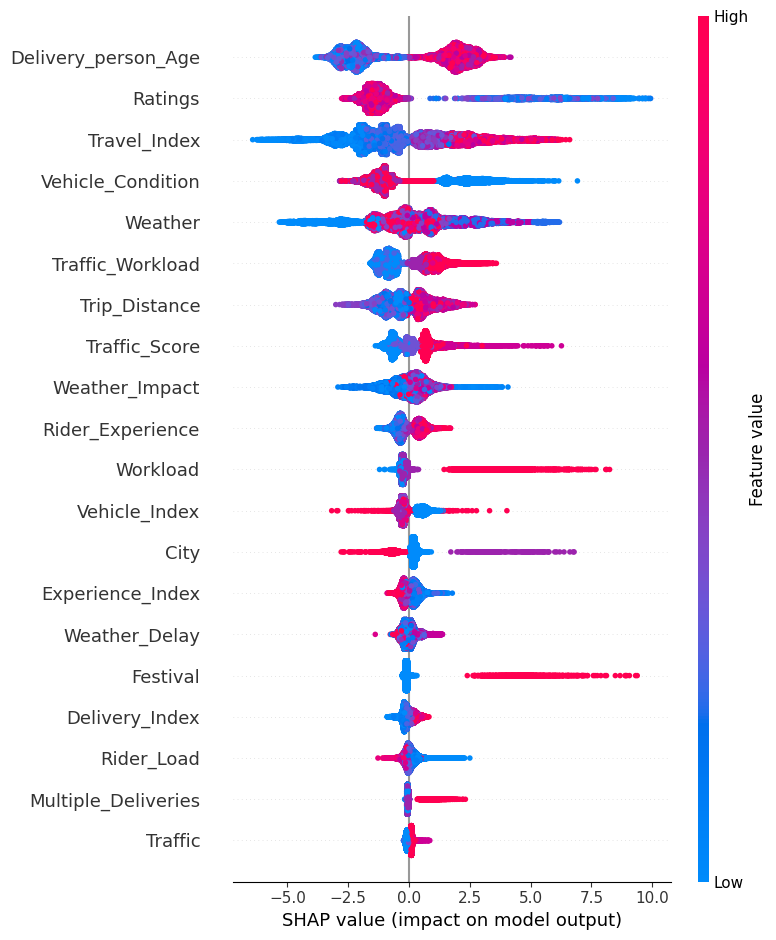

In [10]:
shap.summary_plot(
    shap_values,
    X_processed,
    feature_names=feature_names
)

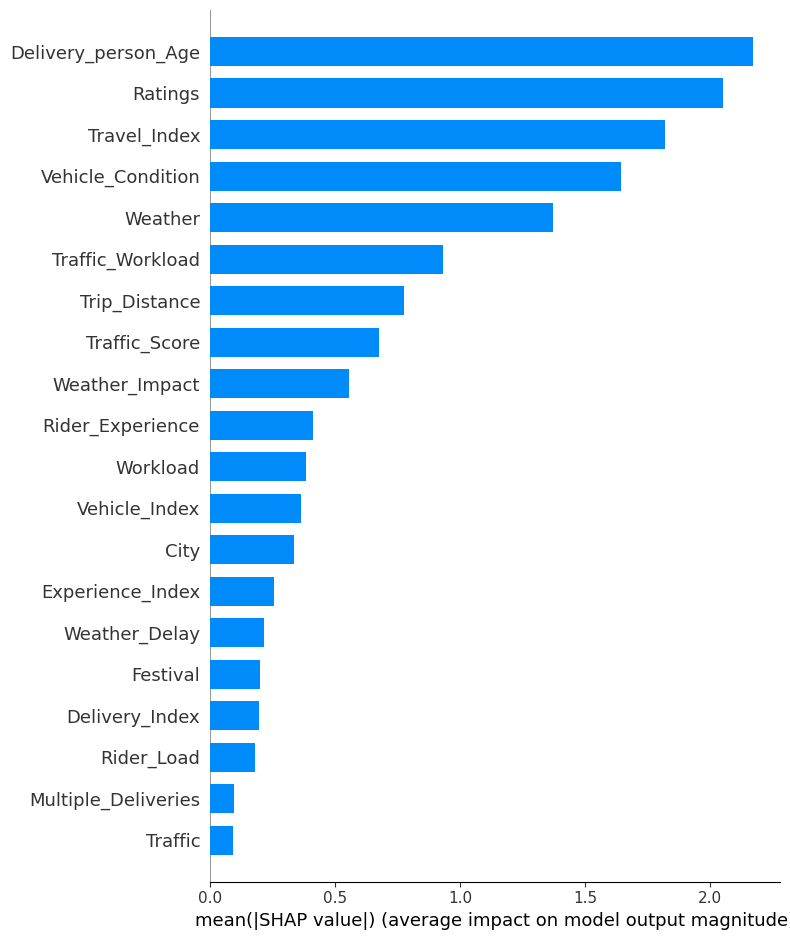

In [11]:
shap.summary_plot(
    shap_values,
    X_processed,
    feature_names=feature_names,
    plot_type="bar"
)

In [12]:
sample = 0

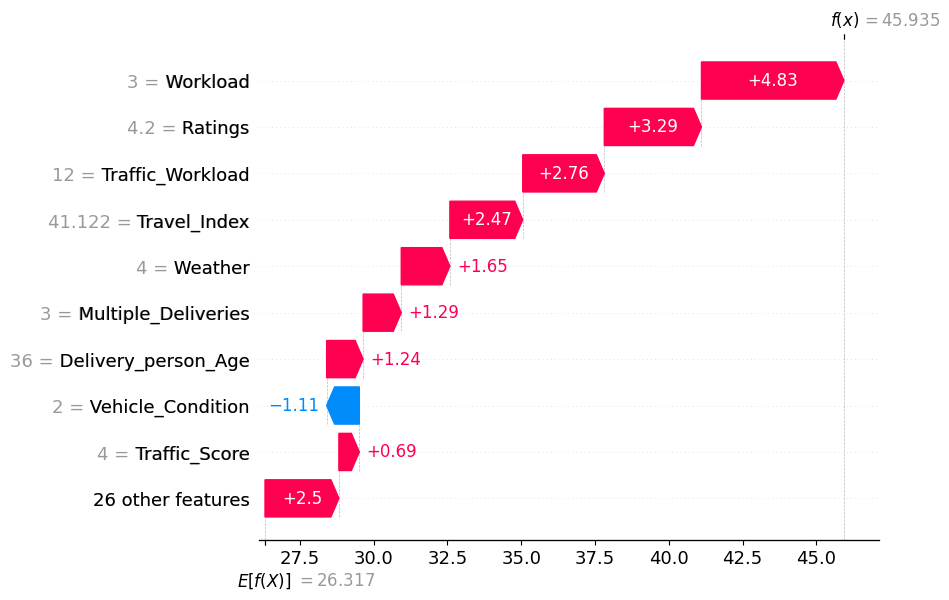

In [13]:
shap.plots.waterfall(

    shap.Explanation(

        values=shap_values[sample],

        base_values=explainer.expected_value,

        data=X_processed[sample],

        feature_names=feature_names

    )

)

In [14]:
shap.initjs()

shap.force_plot(

    explainer.expected_value,

    shap_values[sample],

    X_processed[sample],

    feature_names=feature_names
)

In [15]:
stage_mapping = {

    "O2A":[

        "Traffic_Score",
        "Workload",
        "Rider_Experience",
        "Peak",
        "Festival"

    ],

    "FM":[

        "Trip_Distance",
        "Traffic",
        "Vehicle",
        "Vehicle_Condition"

    ],

    "WT":[

        "Weather",
        "City",
        "Order",
        "Restaurant_Demand"

    ],

    "LM":[

        "Delivery_Index",
        "Weather_Impact",
        "Experience_Index"

    ]

}

In [16]:
stage_scores = {}

for stage, features in stage_mapping.items():

    score = 0

    for feature in features:

        idx = [
            i for i, f in enumerate(feature_names)
            if feature in f
        ]

        if len(idx):

            score += np.mean(
                np.abs(shap_values[:, idx])
            )

    stage_scores[stage] = score

In [17]:
stage_df = pd.DataFrame({

    "Stage": stage_scores.keys(),

    "Importance": stage_scores.values()

})

stage_df

,Stage,Importance
0,O2A,1.966271
1,FM,3.660371
2,WT,1.136982
3,LM,1.011795


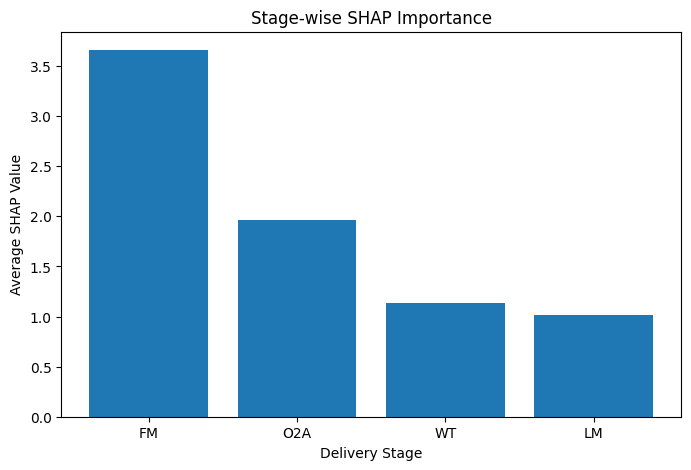

In [18]:
stage_df = stage_df.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,5))

plt.bar(
    stage_df["Stage"],
    stage_df["Importance"]
)

plt.title("Stage-wise SHAP Importance")

plt.xlabel("Delivery Stage")

plt.ylabel("Average SHAP Value")

plt.show()

In [19]:
total = stage_df["Importance"].sum()

stage_df["Contribution (%)"] = (
    stage_df["Importance"] / total
) * 100

stage_df = stage_df.sort_values(
    by="Contribution (%)",
    ascending=False
)

stage_df

,Stage,Importance,Contribution (%)
1,FM,3.660371,47.076193
0,O2A,1.966271,25.288291
2,WT,1.136982,14.622772
3,LM,1.011795,13.012744


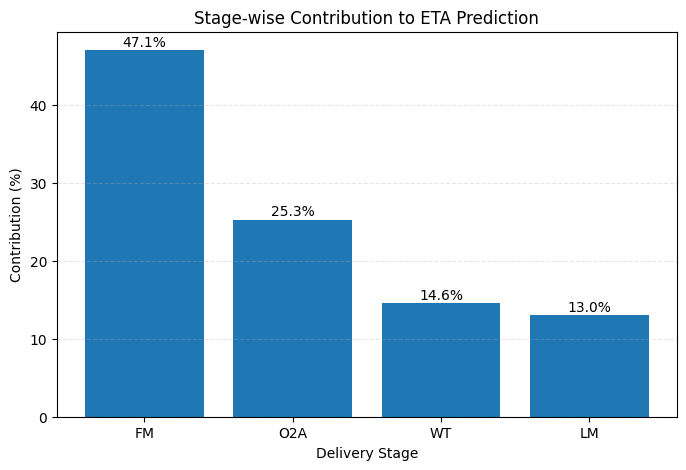

In [20]:
import matplotlib.pyplot as plt

stage_df = stage_df.sort_values(
    by="Contribution (%)",
    ascending=False
)

plt.figure(figsize=(8,5))

bars = plt.bar(
    stage_df["Stage"],
    stage_df["Contribution (%)"]
)

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y + 0.5,
        f"{y:.1f}%",
        ha="center"
    )

plt.title("Stage-wise Contribution to ETA Prediction")
plt.xlabel("Delivery Stage")
plt.ylabel("Contribution (%)")
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()